---

# Блок A: NumPy — массивы, индексация, статистика

## Теория
- `np.ndarray` — основной тип NumPy. Имеет `shape`, `dtype`, `ndim`, `size`.
- Арифметика над массивами выполняется поэлементно.
- Broadcasting позволяет работать с массивами разной формы.
- Используйте векторные операции вместо циклов для скорости.

## A1. Пример

In [4]:
import numpy as np

a = np.arange(20)  # 0..19
print('a shape:', a.shape, 'a dtype:', a.dtype)
A = a.reshape(4, 5)
print('A:\n', A)

even_numbers = A[A % 2 == 0]
print('even_numbers:', even_numbers)

norm_values = np.random.normal(loc=5, scale=2, size=1000)
print('mean:', norm_values.mean(), 'std:', norm_values.std())


a shape: (20,) a dtype: int64
A:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
even_numbers: [ 0  2  4  6  8 10 12 14 16 18]
mean: 5.169592399486789 std: 2.09809418820568


## A2. Задания
1. Создайте массив `a` с 20 числами от 0 до 19 и преобразуйте его в матрицу `A` формы 4x5.
2. Из матрицы `A` получите массив `even_numbers` и вычислите `even_sum`, `even_mean`, `even_std`.
3. Сгенерируйте `norm_values` из 1000 случайных чисел с `loc=5` и `scale=2`.
   Найдите `p10`, `p50`, `p90`.
4. Постройте матрицу `B` 5x5 из чисел 1..25 и замените главную диагональ на 0.
5. Создайте булеву маску `mask_10_20` для элементов `B` от 10 до 20 включительно.
6. Решите систему `A_lin x = b_lin` для случайной невырожденной матрицы `A_lin` и вектора `b_lin`. Сохраните решение в `x_solution`.
7. Создайте сетку `X_grid`, `Y_grid` для диапазона [-2, 2] и вычислите `Z = np.sin(X_grid) * np.cos(Y_grid)`. Найдите `max_coords` — координаты максимума `Z`.

In [5]:
import numpy as np

a = np.arange(20)
A = a.reshape(4, 5)
even_numbers = A[A % 2 == 0]
even_sum = even_numbers.sum()
even_mean = even_numbers.mean()
even_std = even_numbers.std()
norm_values = np.random.normal(loc=5, scale=2, size=1000)
p10 = np.percentile(norm_values, 10)
p50 = np.percentile(norm_values, 50)
p90 = np.percentile(norm_values, 90)
B = np.arange(1, 26).reshape(5, 5)
np.fill_diagonal(B, 0)
mask_10_20 = (B >= 10) & (B <= 20)
A_lin = np.array([[3.0, 1.0, 2.0], [2.0, 4.0, 1.0], [1.0, 3.0, 5.0]])
b_lin = np.array([9.0, 13.0, 20.0])
x_solution = np.linalg.solve(A_lin, b_lin)
X_grid, Y_grid = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
Z = np.sin(X_grid) * np.cos(Y_grid)
max_idx = np.unravel_index(np.argmax(Z), Z.shape)
max_coords = (X_grid[max_idx], Y_grid[max_idx])


---

# Блок B: pandas — загрузка, очистка, группировки

## Теория
- `DataFrame` — основная структура данных. Ее строки идентифицируются `index`, столбцы — `columns`.
- Пропуски обрабатываются методами `isna()`, `dropna()`, `fillna()`.
- `groupby` позволяет вычислять агрегаты по группам.
- `merge`, `concat` и `pivot_table` — ключевые при работе с несколькими таблицами.

## B1. Пример

In [6]:
import pandas as pd
data = {
    'name': ['Anna', 'Boris', 'Cati', 'Dima', 'Eve'],
    'age': [23, None, 22, 35, None],
    'score': [85, 92, None, 73, 88],
    'city': ['Moscow', 'SPB', 'Moscow', 'Kazan', None]
}
df = pd.DataFrame(data)
print(df)
df['age'] = df['age'].fillna(df['age'].median())
df['score'] = df['score'].ffill()
df['city'] = df['city'].fillna('Unknown')
print('\nfilled:')
print(df)
print('\nGroup by city mean score:')
print(df.groupby('city')['score'].mean())


    name   age  score    city
0   Anna  23.0   85.0  Moscow
1  Boris   NaN   92.0     SPB
2   Cati  22.0    NaN  Moscow
3   Dima  35.0   73.0   Kazan
4    Eve   NaN   88.0     NaN

filled:
    name   age  score     city
0   Anna  23.0   85.0   Moscow
1  Boris  23.0   92.0      SPB
2   Cati  22.0   92.0   Moscow
3   Dima  35.0   73.0    Kazan
4    Eve  23.0   88.0  Unknown

Group by city mean score:
city
Kazan      73.0
Moscow     88.5
SPB        92.0
Unknown    88.0
Name: score, dtype: float64


## B2. Задания
1. Создайте DataFrame `students` с 10 строками: name, age, score, city.
2. Сохраните его в CSV и загрузите обратно в `students_loaded`.
3. Приведите `age` к `int`, заполните пропуски: age — медианой, score — backward-fill, city — 'Unknown'.
4. Добавьте столбец `passed`: `score >= 60`. Отфильтруйте `failed_students`.
5. Сгруппируйте по `city`: `avg_score`, `median_age`, `count`. Сохраните в `city_stats`.
6. В одной цепочке выполните загрузку, очистку, добавление столбца `rank` по `score` и сортировку.

In [7]:
import pandas as pd
students = pd.DataFrame({
    'name': ['Anna', 'Boris', 'Cati', 'Dima', 'Eve', 'Fedor', 'Gina', 'Hugo', 'Ira', 'John'],
    'age': [23, 26, None, 35, 29, 18, 40, None, 31, 27],
    'score': [85, 55, 68, 73, 88, 49, 95, 77, None, 62],
    'city': ['Moscow', 'SPB', 'Moscow', 'Kazan', 'SPB', 'Kazan', None, 'Moscow', 'SPB', 'Kazan']
})
students.to_csv('students_practice.csv', index=False)
students_loaded = pd.read_csv('students_practice.csv')
students_loaded['age'] = students_loaded['age'].fillna(students_loaded['age'].median()).astype(int)
students_loaded['score'] = students_loaded['score'].bfill()
students_loaded['city'] = students_loaded['city'].fillna('Unknown')
students_loaded['passed'] = students_loaded['score'] >= 60
failed_students = students_loaded[~students_loaded['passed']]
city_stats = students_loaded.groupby('city').agg(avg_score=('score', 'mean'), median_age=('age', 'median'), count=('name', 'count')).reset_index()
students_ranked = (pd.read_csv('students_practice.csv')
                 .assign(age=lambda d: d['age'].fillna(d['age'].median()).astype(int),
                         score=lambda d: d['score'].bfill(),
                         city=lambda d: d['city'].fillna('Unknown'))
                 .assign(rank=lambda d: d['score'].rank(method='dense', ascending=False))
                 .sort_values('rank'))


---

# Блок C: Matplotlib — визуализация данных

## Теория
- Линейные графики показывают динамику.
- Scatter plot изучает зависимость между двумя признаками.
- Гистограммы визуализируют распределение.
- `subplots` удобно сравнивать несколько графиков вместе.

## C1. Пример

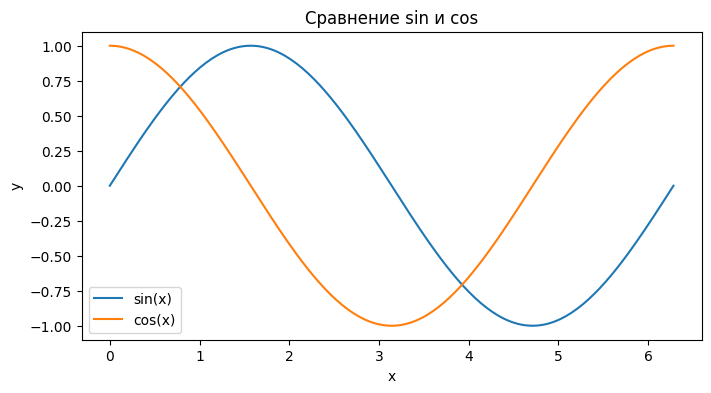

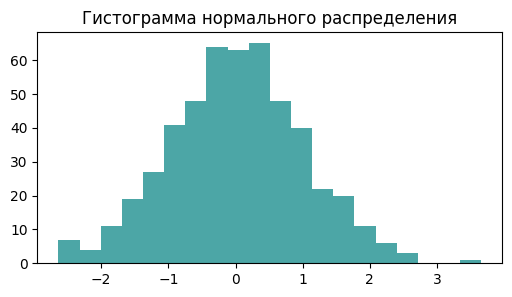

In [8]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.style.use('default')
plt.figure(figsize=(8, 4))
plt.plot(x, y_sin, label='sin(x)')
plt.plot(x, y_cos, label='cos(x)')
plt.title('Сравнение sin и cos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

hist_data = np.random.normal(size=500)
plt.figure(figsize=(6, 3))
plt.hist(hist_data, bins=20, color='teal', alpha=0.7)
plt.title('Гистограмма нормального распределения')
plt.show()


## C2. Задания
1. Постройте `x`, `y_sin`, `y_cos` и график sin/cos с легендой.
2. Постройте гистограмму `hist_data` из 500 нормальных чисел.
3. Создайте scatter-график с `scatter_x`, `scatter_y`, `scatter_color` и `scatter_size`.
4. Постройте `bar chart` и `pie chart` на `subplots`.
5. Постройте тепловую карту `heatmap_Z` для `np.sin(X)*np.cos(Y)` с помощью `imshow`.
6. С помощью `twinx` отобразите два ряда на разных осях.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)
hist_data = np.random.normal(size=500)
scatter_x = np.random.rand(100)
scatter_y = np.random.rand(100)
scatter_color = np.random.randn(100)
scatter_size = (np.abs(scatter_color) + 0.5) * 50
X, Y = np.meshgrid(np.linspace(-2, 2, 30), np.linspace(-2, 2, 30))
heatmap_Z = np.sin(X) * np.cos(Y)
dates = np.arange('2024-01-01', '2024-02-01', dtype='datetime64[D]')
series1 = np.linspace(10, 20, len(dates)) + np.random.randn(len(dates))
series2 = np.linspace(5, 15, len(dates)) + np.random.randn(len(dates)) * 1.5


---

# Блок D: scikit-learn — подготовка, модели, оценка

## Теория
- train/test нужен для оценки обобщения.
- StandardScaler стандартизует признаки, это важно для многих моделей.
- Pipeline объединяет preprocessing и модель.
- GridSearchCV помогает находить лучшие параметры по кросс-валидации.
- PCA сокращает размерность, сохраняя значимую вариативность.

## D1. Пример

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print('accuracy:', accuracy_score(y_test, y_pred))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
print('explained variance ratio:', pca.explained_variance_ratio_)


accuracy: 0.9111111111111111
explained variance ratio: [0.72962445 0.22850762]


## D2. Задания
1. Загрузите `iris`, разделите train/test 70/30 со `stratify`.
2. Соберите `Pipeline` StandardScaler + LogisticRegression и обучите модель.
3. Оцените `accuracy` на тесте.
4. Выполните `cross_val_score` (cv=5) и сравните с точностью на тесте.
5. Используйте `GridSearchCV` для параметров `C` и `penalty`, найдите `best_params_`.
6. На `diabetes` обучите `LinearRegression`, вычислите `mse_diabetes` и `r2_diabetes`.

In [11]:
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(pipe, X, y, cv=5)
params = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2']}
grid = GridSearchCV(pipe, params, cv=5)
grid.fit(X_train, y_train)
best_params = grid.best_params_
diabetes = load_diabetes(as_frame=True)
X_dia = diabetes.data
y_dia = diabetes.target
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dia, y_dia, test_size=0.3, random_state=42)
lm = LinearRegression()
lm.fit(X_train_d, y_train_d)
preds_dia = lm.predict(X_test_d)
mse_diabetes = mean_squared_error(y_test_d, preds_dia)
r2_diabetes = r2_score(y_test_d, preds_dia)


c:\Users\Dmitry Dogotar\OneDrive\Documents\python_projects\DS_Gemini\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dmitry Dogotar\OneDrive\Documents\python_projects\DS_Gemini\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dmitry Dogotar\OneDrive\Documents\python_projects\DS_Gemini\.venv\Lib\site-packages\sklearn\linea

---

# Экзамен: интегрированный проект

## Задача
Сгенерируйте синтетические данные, выполните очистку, визуализацию и модель.

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
N = 200
age = np.random.randint(18, 80, size=N).astype(float)
income = np.random.normal(50000, 15000, size=N)
visits = np.random.poisson(5, size=N)
spend = np.round(np.abs(np.random.normal(300, 120, size=N) + visits * 20 + income / 10000), 2)
city = np.random.choice(['Moscow', 'SPB', 'Kazan', 'Novosib'], size=N)
age[np.random.choice(N, 10, replace=False)] = np.nan
city[np.random.choice(N, 10, replace=False)] = None
exam_df = pd.DataFrame({'age': age, 'income': income, 'visits': visits, 'spend': spend, 'city': city})
exam_df['age'] = exam_df['age'].fillna(exam_df['age'].median())
exam_df['city'] = exam_df['city'].fillna('Unknown')
exam_df['spend_per_visit'] = exam_df['spend'] / (exam_df['visits'] + 1)
exam_df['income_to_age'] = exam_df['income'] / (exam_df['age'] + 1)
exam_df['high_spender'] = (exam_df['spend'] > exam_df['spend'].median()).astype(int)
exam_X = exam_df[['age', 'income', 'visits', 'spend_per_visit', 'income_to_age']]
exam_y = exam_df['high_spender']
exam_X_train, exam_X_test, exam_y_train, exam_y_test = train_test_split(exam_X, exam_y, test_size=0.3, stratify=exam_y, random_state=42)
scaler = StandardScaler()
exam_X_train_s = scaler.fit_transform(exam_X_train)
exam_X_test_s = scaler.transform(exam_X_test)
clf = LogisticRegression(max_iter=200)
clf.fit(exam_X_train_s, exam_y_train)
exam_y_pred = clf.predict(exam_X_test_s)
exam_accuracy = accuracy_score(exam_y_test, exam_y_pred)
exam_confusion = confusion_matrix(exam_y_test, exam_y_pred)
exam_report = classification_report(exam_y_test, exam_y_pred)
